In [1]:
import requests
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import argrelextrema
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette("colorblind")

## DATA PREPARATION - EXAMPLE
**1. Connecting to Massive API and downloading historical stock data via REST Endpoint:** We will fetch the data natively via requests using our API Key, parse the JSON, and map the object's keys to reproduce the exact same DataFrame geometry as before so no downstream technical indicator calculations break.

In [2]:
end_date = datetime.now()
start_date = end_date - timedelta(weeks=8)

# Format dates for API (YYYY-MM-DD)
str_end = end_date.strftime("%Y-%m-%d")
str_start = start_date.strftime("%Y-%m-%d")

API_KEY = "XlyEMmsptpVKTJPVtbOf6FDMTct92fA3"
symbol = "AAPL"
url = f"https://api.polygon.io/v2/aggs/ticker/{symbol}/range/1/hour/{str_start}/{str_end}?adjusted=false&sort=asc&apiKey={API_KEY}"

response = requests.get(url)
data = response.json()

if "results" in data:
    df = pd.DataFrame(data["results"])
    # Rename Massive API keys to typical format
    df = df.rename(columns={
        "o": "Open",
        "h": "High",
        "l": "Low",
        "c": "Close",
        "v": "Volume",
        "t": "Datetime"
    })
    
    # Convert Unix timestamps to datetime index
    df['Datetime'] = pd.to_datetime(df['Datetime'], unit='ms')
    df.set_index('Datetime', inplace=True)
else:
    print(f"Error fetching data: {data}")

df.head()

,Volume,vw,Open,Close,High,Low,n
Datetime,,,,,,,
2026-01-14 09:00:00,23063.0,260.4707,260.56,260.4000,260.8300,260.1900,706
2026-01-14 10:00:00,32806.0,259.9160,260.40,259.9300,260.4000,259.6000,1478
2026-01-14 11:00:00,22852.0,259.8054,259.80,259.6000,260.0100,259.5900,858
2026-01-14 12:00:00,42599.0,259.8557,259.71,260.1000,260.3300,259.2500,1367
2026-01-14 13:00:00,122921.0,259.9957,259.60,259.9999,260.7379,259.2537,6097


2. Extracting the Close Price Data and scaling it between 0-1.

In [3]:
df["idx"] = range(len(df))
# df columns: Open, High, Low, Close, Adj Close, Volume, idx
close = df["Close"].dropna()
open = df["Open"].dropna()

close_prices = close.values.reshape(-1, 1)
open_prices = open.values.reshape(-1, 1)

In [4]:
# Create the scaler and fit-transform
price_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = price_scaler.fit_transform(close_prices).flatten()
scaled_open = price_scaler.fit_transform(open_prices).flatten()

# Add them back to your dataframe
df["Scaled_Close"] = scaled_close
df["Scaled_Open"] = scaled_open

# ---------- 3) Calculate RSI ----------
# We calculate RSI here before finding the segments so we can extract it later.
delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -1 * delta.clip(upper=0)
ema_gain = gain.ewm(com=13, adjust=False).mean()
ema_loss = loss.ewm(com=13, adjust=False).mean()
rs = ema_gain / ema_loss
df["RSI"] = 100 - (100 / (1 + rs))
df["RSI"] = df["RSI"].fillna(50)

**RSI Calculation:** We compute a standard 14-period Relative Strength Index to act as a momentum indicator. Later, when extracting $y=mx+b$ swings, we'll grab this RSI value exactly at the start of the swing to give the predictive algorithm context regarding whether the stock was overbought or oversold.

3. Defining functions to normalize the Time value of each row in our stock data.

In [5]:
def infer_interval_minutes(idx: pd.DatetimeIndex) -> int:
    """
    Infer the candle size in minutes from a DatetimeIndex.
    We look at within-day consecutive time differences and take the most common (mode).
    """
    if len(idx) < 2:
        return 0

    # Turn the index into a Series so we can use .diff() to get consecutive gaps as Timedeltas
    s = idx.to_series()

    # Differences between adjacent timestamps (Timedelta)
    gaps = s.diff()  # first value is NaT

    # Keep only differences that occur within the same calendar day (skip overnight/weekend jumps)
    same_day = s.dt.date == s.shift(1).dt.date
    gaps_same_day = gaps[same_day]  # Timedeltas like 0:01:00, 1:00:00, etc.

    if gaps_same_day.empty:
        # Fallback: use all gaps if we somehow have no within-day segments
        gaps_same_day = gaps.dropna()

    # Convert Timedelta to minutes (float)
    gaps_min = gaps_same_day.dt.total_seconds() / 60.0

    if gaps_min.empty:
        return 0

    # Most common gap (mode) rounded to nearest integer minute
    step = int(round(gaps_min.mode().iloc[0]))
    return max(step, 1)  # never return 0

In [6]:
def trading_clock_minutes(idx: pd.DatetimeIndex) -> np.ndarray:
    """
    Return a 0-based time axis in minutes that advances by the inferred candle size.
    Example: for 1h candles, returns [0, 60, 120, 180, ...].
    """
    step = infer_interval_minutes(idx)
    if step == 0:
        step = 60  # safe fallback
    n = len(idx)
    return np.arange(n, dtype=float) * step

In [7]:
t_minutes = trading_clock_minutes(df.index)  # starts at 0, increases by candle size
df["t_minutes"] = t_minutes

# time scaling
time_scaler = MinMaxScaler()
df["Scaled_Time"] = time_scaler.fit_transform(df[["t_minutes"]]).flatten()
"""# Optional: if you want to “view” timestamps in Israel time (not required for the trading clock):
df = df.tz_convert("Asia/Jerusalem") if df.index.tz is not None else df"""

'# Optional: if you want to “view” timestamps in Israel time (not required for the trading clock):\ndf = df.tz_convert("Asia/Jerusalem") if df.index.tz is not None else df'

5. Calculating the attributes of each $y = mx + b$ function we found, and appending contextual trading data (Volume, RSI, Volatility) for the Machine Learning model.

In [8]:
# ---------- 2) Find extrema (peaks/lows) ----------
order = 5  # tune this to control how "major" a turn must be
data = df["Scaled_Close"].values
max_idx = argrelextrema(data, np.greater, order=order)[0]
min_idx = argrelextrema(data, np.less,   order=order)[0]

# Merge extrema into a single time-ordered sequence so segments are consecutive turns:
ext_idx = np.sort(np.concatenate([max_idx, min_idx]))
# (If you need the label of each, you can carry a dict {idx: 'max'/'min'}.)

5. Calculating the attributes of each y = mx + b function we found.

In [10]:
# ---------- 3) Build segments with your exact definitions ----------
segments = []
for i in range(len(ext_idx) - 1):
    idx0, idx1 = int(ext_idx[i]), int(ext_idx[i+1])
    idx_diff = idx1 - idx0

    t0 = df["Scaled_Time"].iloc[idx0]
    t1 = df["Scaled_Time"].iloc[idx1]
    y0 = float(df["Scaled_Close"].iloc[idx0])
    y1 = float(df["Scaled_Close"].iloc[idx1])

    dt = (t1 - t0)  # minutes on your trading clock
    if dt == 0:
        # degenerate (shouldn’t happen with proper extrema), skip
        continue

    # Your definitions:
    # 1) m: slope using minutes as x
    m = (y1 - y0) / dt

    # 2) b: intercept in global coordinates (where global x=0 at the first candle)
    #    i.e., line y = m*x + b that passes through (t0, y0)
    b = y0 - m * t0

    # 3) time_delta in minutes
    time_delta = dt

    # 4) Contextual features
    v_sum = df["Volume"].iloc[idx0:idx1].sum()
    volume_sum = float(v_sum.item() if isinstance(v_sum, pd.Series) else v_sum)
    rsi_start = float(df["RSI"].iloc[idx0].item() if isinstance(df["RSI"].iloc[idx0], pd.Series) else df["RSI"].iloc[idx0])
    
    # Volatility (Standard deviation of regular Close prices in this segment)
    vol_calc = df["Close"].iloc[idx0:idx1].std()
    
    if isinstance(vol_calc, pd.Series):
        volatility = float(vol_calc.item()) if pd.notna(vol_calc).all() else 0.0
    else:
        volatility = float(vol_calc) if pd.notna(vol_calc) else 0.0

    segments.append({
        "idx_start": idx0,
        "idx_end":   idx1,
        "idx_diff": idx_diff,
        "t_start": t0,
        "t_end":   t1,
        "y_start": y0,
        "y_end":   y1,
        "m": m,
        "b": b,
        "time_delta_min": time_delta,
        "volume_sum": volume_sum,
        "rsi_start": rsi_start,
        "volatility": volatility
    })

segments_df = pd.DataFrame(segments)

**Adding Context:** In the block above, rather than purely identifying the start point and calculating the $y=mx+b$ slope, we look *inside* the extracted swing `[idx0:idx1]` and extract Volume, Volatility, and the Starting RSI. This adds highly necessary context to the swing that gives prediction models the actual characteristics of *how* the swing happened, not just where it started and ended.

In [11]:
df.head(10) 

,Volume,vw,Open,Close,High,Low,n,idx,Scaled_Close,Scaled_Open,RSI,t_minutes,Scaled_Time
Datetime,,,,,,,,,,,,,
2026-01-14 09:00:00,23063.0,260.4707,260.56,260.4000,260.8300,260.1900,706,0,1.000000,1.000000,50.000000,0.0,0.000000
2026-01-14 10:00:00,32806.0,259.9160,260.40,259.9300,260.4000,259.6000,1478,1,0.969140,0.989730,0.000000,60.0,0.009615
2026-01-14 11:00:00,22852.0,259.8054,259.80,259.6000,260.0100,259.5900,858,2,0.947472,0.951220,0.000000,120.0,0.019231
2026-01-14 12:00:00,42599.0,259.8557,259.71,260.1000,260.3300,259.2500,1367,3,0.980302,0.945443,7.716049,180.0,0.028846
2026-01-14 13:00:00,122921.0,259.9957,259.60,259.9999,260.7379,259.2537,6097,4,0.973729,0.938383,7.589787,240.0,0.038462
2026-01-14 14:00:00,4367307.0,260.0266,259.96,259.1000,261.8200,259.0300,86098,5,0.914642,0.961489,6.551817,300.0,0.048077
2026-01-14 15:00:00,5163123.0,259.4522,259.18,258.0710,260.9500,257.8600,137750,6,0.847078,0.911425,5.607476,360.0,0.057692
2026-01-14 16:00:00,3408271.0,258.1270,258.07,257.6800,258.9600,257.2500,114118,7,0.821405,0.840180,5.295162,420.0,0.067308
2026-01-14 17:00:00,2830942.0,257.3547,257.72,257.2600,258.0500,256.7100,62280,8,0.793828,0.817715,4.974650,480.0,0.076923


In [ ]:
relevant_df = df[["Close", "Scaled_Close", "Scaled_Time", "idx"]]
relevant_df.head(10)

In [12]:
segments_df.tail()

,idx_start,idx_end,idx_diff,t_start,t_end,y_start,y_end,m,b,time_delta_min,volume_sum,rsi_start,volatility
8,81,89,8,0.778846,0.855769,0.318450,0.331582,0.170716,0.185489,0.076923,17746550.0,54.695858,0.422976
9,89,92,3,0.855769,0.884615,0.331582,0.196980,-4.666229,4.324798,0.028846,13744028.0,55.349800,0.961722
10,92,95,3,0.884615,0.913462,0.196980,0.247538,1.752681,-1.353469,0.028846,1491488.0,45.005796,0.338506
11,95,101,6,0.913462,0.971154,0.247538,0.047275,-3.471219,3.418363,0.057692,290655.0,49.455726,0.448170
12,101,102,1,0.971154,0.980769,0.047275,0.250164,21.100460,-20.444517,0.009615,7111689.0,33.949773,0.000000


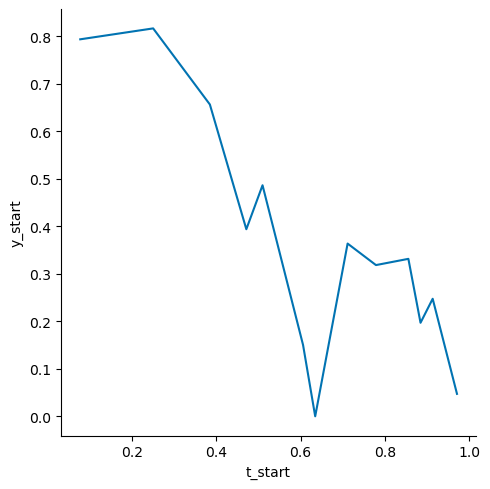

In [13]:
ax = sns.relplot(x = "t_start", y = "y_start", kind="line", data = segments_df)